In [1]:
from artcir_thesis.dataset import ArtCIRDataset

/nfs/home/rivera/artkb-dataset/ArtCIR-thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
path = '../data/artcir'
query_dataset = ArtCIRDataset(annotation_path_prefix=path+'/annotations', 
                        image_path_prefix=path+'/images',
                        type="query")
candidate_dataset = ArtCIRDataset(annotation_path_prefix=path+'/annotations', 
                        image_path_prefix=path+'/images',
                        type="image")

In [ ]:
from models.qwen3_vl_embedding import Qwen3VLEmbedder
import numpy as np
import torch

# Define a list of query texts
queries = [
    {"text": "A woman playing with her dog on a beach at sunset."},
    {"text": "Pet owner training dog outdoors near water."},
    {"text": "Woman surfing on waves during a sunny day."},
    {"text": "City skyline view from a high-rise building at night."}
]

# Define a list of document texts and images
documents = [
    {"text": "A woman shares a joyful moment with her golden retriever on a sun-drenched beach at sunset, as the dog offers its paw in a heartwarming display of companionship and trust."},
    {"image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg"},
    {"text": "A woman shares a joyful moment with her golden retriever on a sun-drenched beach at sunset, as the dog offers its paw in a heartwarming display of companionship and trust.", "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg"}
]

# Specify the model path
model_name_or_path = "Qwen/Qwen3-VL-Embedding-2B"

# Initialize the Qwen3VLEmbedder model
model = Qwen3VLEmbedder(model_name_or_path=model_name_or_path, 
                        torch_dtype=torch.float16)
# We recommend enabling flash_attention_2 for better acceleration and memory saving,
# model = Qwen3VLEmbedder(model_name_or_path=model_name_or_path, torch_dtype=torch.float16, attn_implementation="flash_attention_2")

# Combine queries and documents into a single input list
inputs = queries + documents

# Process the inputs to get embeddings
embeddings = model.process(inputs)

# # Compute similarity scores between query embeddings and document embeddings
# similarity_scores = (embeddings[:4] @ embeddings[4:].T)

# # Print out the similarity scores in a list format
# print(similarity_scores.tolist())

# # [[0.8157786130905151, 0.7178360223770142, 0.7173429131507874], [0.5195091962814331, 0.3302568793296814, 0.4391537308692932], [0.3884059488773346, 0.285782128572464, 0.33141762018203735], [0.1092604324221611, 0.03871120512485504, 0.06952016055583954]]


/nfs/home/rivera/artkb-dataset/ArtCIR-thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 625/625 [00:03<00:00, 173.49it/s]


In [ ]:
print(embeddings.shape)

In [6]:
embeddings = model.process([query_dataset[0][0]] + [candidate_dataset[i][0] for i in range(5)])

In [7]:
embeddings[0] @ embeddings[1:].T

tensor([0.2158, 0.3757, 0.2673, 0.3074, 0.2438], dtype=torch.float16)

In [8]:
query_dataset[0]

({'instruction': "I'm looking for a similar painting with the described changes.",
  'text': 'Change the setting to a bedroom with a man on a bed under purple drapes.',
  'image': '../data/artcir/images/fee15b63-3028-4db4-b83b-97ed5118d5a8.jpeg'},
 0)

In [13]:
from PIL import Image

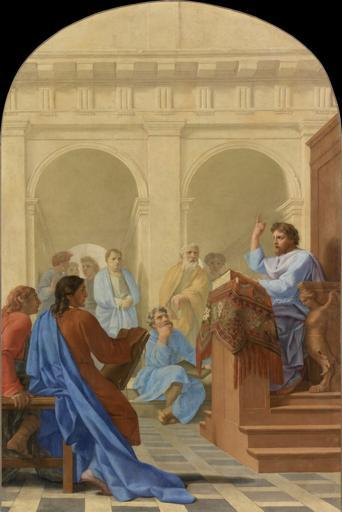

In [14]:
Image.open('../data/artcir/images/fee15b63-3028-4db4-b83b-97ed5118d5a8.jpeg')

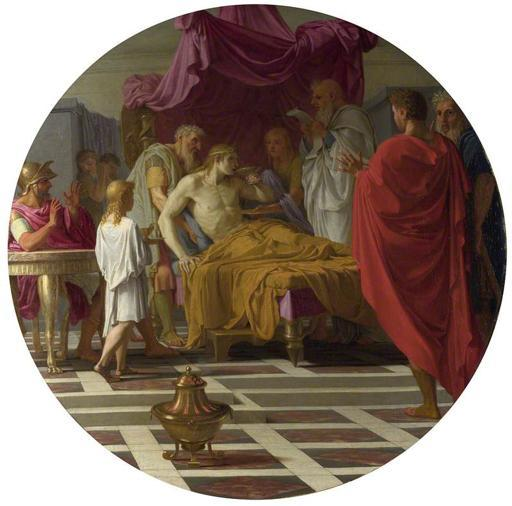

In [21]:
Image.open('../data/artcir/images/71c55480-2167-4a53-bae9-379a5b469a19.jpeg')

In [29]:
candidate_dataset[:5][0]['image']

['../data/artcir/images/98ce12c8-1bc8-4ee2-9a72-cd404f79dbd3.jpeg',
 '../data/artcir/images/19da8dba-c041-4755-90ae-1cb653c64759.jpeg',
 '../data/artcir/images/000831fd-3804-43c7-8fd7-d9149fcf6b89.jpeg',
 '../data/artcir/images/00153000-4acd-42d6-b1c8-efd185e76dfc.jpeg',
 '../data/artcir/images/00186473-bf6c-45b1-849d-8482d0758d6f.jpeg']

In [31]:
candidate_dataset[0]

({'image': '../data/artcir/images/98ce12c8-1bc8-4ee2-9a72-cd404f79dbd3.jpeg'},
 0)

In [32]:
t = model.process([{'image': '../data/artcir/images/71c55480-2167-4a53-bae9-379a5b469a19.jpeg'}])

In [33]:
embeddings[0] @ t.T

tensor([0.5845], dtype=torch.float16)

In [34]:
len(candidate_dataset), len(query_dataset)

(31899, 3088)

In [35]:
query_dataset.annotations

[{'qid': 'http://www.wikidata.org/entity/Q29845256_http://www.wikidata.org/entity/Q26713276',
  'reference_qid': 'http://www.wikidata.org/entity/Q29845256',
  'target_qid': 'http://www.wikidata.org/entity/Q26713276',
  'instruction': 'Change the setting to a bedroom with a man on a bed under purple drapes.'},
 {'qid': 'http://www.wikidata.org/entity/Q26713276_http://www.wikidata.org/entity/Q29845256',
  'reference_qid': 'http://www.wikidata.org/entity/Q26713276',
  'target_qid': 'http://www.wikidata.org/entity/Q29845256',
  'instruction': 'Change the bedside scene to Saint Bruno teaching theology in a school hall.'},
 {'qid': 'http://www.wikidata.org/entity/Q104446177_http://www.wikidata.org/entity/Q29845256',
  'reference_qid': 'http://www.wikidata.org/entity/Q104446177',
  'target_qid': 'http://www.wikidata.org/entity/Q29845256',
  'instruction': 'Replace the angelic assembly with Saint Bruno teaching theology in a classical hall.'},
 {'qid': 'http://www.wikidata.org/entity/Q10685457